In [2]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv('US_Accidents_March23.csv')
df

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.010,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.010,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.010,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.010,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.010,...,False,False,False,False,True,False,Day,Day,Day,Day
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7728389,A-7777757,Source1,2,2019-08-23 18:03:25,2019-08-23 18:32:01,34.002480,-117.379360,33.99888,-117.37094,0.543,...,False,False,False,False,False,False,Day,Day,Day,Day
7728390,A-7777758,Source1,2,2019-08-23 19:11:30,2019-08-23 19:38:23,32.766960,-117.148060,32.76555,-117.15363,0.338,...,False,False,False,False,False,False,Day,Day,Day,Day
7728391,A-7777759,Source1,2,2019-08-23 19:00:21,2019-08-23 19:28:49,33.775450,-117.847790,33.77740,-117.85727,0.561,...,False,False,False,False,False,False,Day,Day,Day,Day
7728392,A-7777760,Source1,2,2019-08-23 19:00:21,2019-08-23 19:29:42,33.992460,-118.403020,33.98311,-118.39565,0.772,...,False,False,False,False,False,False,Day,Day,Day,Day


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     str    
 1   Source                 str    
 2   Severity               int64  
 3   Start_Time             str    
 4   End_Time               str    
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   End_Lat                float64
 8   End_Lng                float64
 9   Distance(mi)           float64
 10  Description            str    
 11  Street                 str    
 12  City                   str    
 13  County                 str    
 14  State                  str    
 15  Zipcode                str    
 16  Country                str    
 17  Timezone               str    
 18  Airport_Code           str    
 19  Weather_Timestamp      str    
 20  Temperature(F)         float64
 21  Wind_Chill(F)          float64
 22  Humidity(%)            float6

In [5]:
df.describe()

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,7.728394e+06,7.728394e+06,7.728394e+06,4.325632e+06,4.325632e+06,7.728394e+06,7.564541e+06,5.729375e+06,7.554250e+06,7.587715e+06,7.551296e+06,7.157161e+06,5.524808e+06
mean,2.212384e+00,3.620119e+01,-9.470255e+01,3.626183e+01,-9.572557e+01,5.618423e-01,6.166329e+01,5.825105e+01,6.483104e+01,2.953899e+01,9.090376e+00,7.685490e+00,8.407210e-03
std,4.875313e-01,5.076079e+00,1.739176e+01,5.272905e+00,1.810793e+01,1.776811e+00,1.901365e+01,2.238983e+01,2.282097e+01,1.006190e+00,2.688316e+00,5.424983e+00,1.102246e-01
min,1.000000e+00,2.455480e+01,-1.246238e+02,2.456601e+01,-1.245457e+02,0.000000e+00,-8.900000e+01,-8.900000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.000000e+00,3.339963e+01,-1.172194e+02,3.346207e+01,-1.177543e+02,0.000000e+00,4.900000e+01,4.300000e+01,4.800000e+01,2.937000e+01,1.000000e+01,4.600000e+00,0.000000e+00
50%,2.000000e+00,3.582397e+01,-8.776662e+01,3.618349e+01,-8.802789e+01,3.000000e-02,6.400000e+01,6.200000e+01,6.700000e+01,2.986000e+01,1.000000e+01,7.000000e+00,0.000000e+00
75%,2.000000e+00,4.008496e+01,-8.035368e+01,4.017892e+01,-8.024709e+01,4.640000e-01,7.600000e+01,7.500000e+01,8.400000e+01,3.003000e+01,1.000000e+01,1.040000e+01,0.000000e+00
max,4.000000e+00,4.900220e+01,-6.711317e+01,4.907500e+01,-6.710924e+01,4.417500e+02,2.070000e+02,2.070000e+02,1.000000e+02,5.863000e+01,1.400000e+02,1.087000e+03,3.647000e+01


In [6]:
df.drop(columns=[
    'End_Lat',
    'End_Lng',
    'Wind_Chill(F)',
    'Precipitation(in)',
    'Description',
    'Street'
],inplace=True)

In [7]:
df['Temperature(F)'] = df['Temperature(F)'].fillna(df['Temperature(F)'].median())
df['Humidity(%)'] = df['Humidity(%)'].fillna(df['Humidity(%)'].median())
df['Pressure(in)'] = df['Pressure(in)'].fillna(df['Pressure(in)'].median())
df['Visibility(mi)'] = df['Visibility(mi)'].fillna(df['Visibility(mi)'].median())
df['Wind_Speed(mph)'] = df['Wind_Speed(mph)'].fillna(df['Wind_Speed(mph)'].median())


In [8]:
missing = (df.isnull().sum() / len(df)) * 100
missing.sort_values(ascending=False)

Wind_Direction           2.267043
Weather_Condition        2.244438
Weather_Timestamp        1.555666
Sunrise_Sunset           0.300787
Nautical_Twilight        0.300787
Civil_Twilight           0.300787
Astronomical_Twilight    0.300787
Airport_Code             0.292881
Timezone                 0.101030
Zipcode                  0.024779
City                     0.003274
End_Time                 0.000000
Start_Time               0.000000
Severity                 0.000000
Source                   0.000000
ID                       0.000000
Distance(mi)             0.000000
Start_Lng                0.000000
Start_Lat                0.000000
Humidity(%)              0.000000
Country                  0.000000
State                    0.000000
Temperature(F)           0.000000
County                   0.000000
Amenity                  0.000000
Wind_Speed(mph)          0.000000
Pressure(in)             0.000000
Visibility(mi)           0.000000
Bump                     0.000000
Crossing      

In [9]:
df.isnull().sum()

ID                            0
Source                        0
Severity                      0
Start_Time                    0
End_Time                      0
Start_Lat                     0
Start_Lng                     0
Distance(mi)                  0
City                        253
County                        0
State                         0
Zipcode                    1915
Country                       0
Timezone                   7808
Airport_Code              22635
Weather_Timestamp        120228
Temperature(F)                0
Humidity(%)                   0
Pressure(in)                  0
Visibility(mi)                0
Wind_Direction           175206
Wind_Speed(mph)               0
Weather_Condition        173459
Amenity                       0
Bump                          0
Crossing                      0
Give_Way                      0
Junction                      0
No_Exit                       0
Railway                       0
Roundabout                    0
Station 

In [10]:
df.drop(columns=[
    'Zipcode',
    'Timezone',
    'Airport_Code',
    'Weather_Timestamp',
    'Civil_Twilight',
    'Nautical_Twilight',
    'Astronomical_Twilight'
], inplace=True)

In [11]:
df.isnull().sum()

ID                        0
Source                    0
Severity                  0
Start_Time                0
End_Time                  0
Start_Lat                 0
Start_Lng                 0
Distance(mi)              0
City                    253
County                    0
State                     0
Country                   0
Temperature(F)            0
Humidity(%)               0
Pressure(in)              0
Visibility(mi)            0
Wind_Direction       175206
Wind_Speed(mph)           0
Weather_Condition    173459
Amenity                   0
Bump                      0
Crossing                  0
Give_Way                  0
Junction                  0
No_Exit                   0
Railway                   0
Roundabout                0
Station                   0
Stop                      0
Traffic_Calming           0
Traffic_Signal            0
Turning_Loop              0
Sunrise_Sunset        23246
dtype: int64

In [12]:
df.dropna(subset=['City', 'Sunrise_Sunset'], inplace=True)

In [13]:
df.isnull().sum()


ID                        0
Source                    0
Severity                  0
Start_Time                0
End_Time                  0
Start_Lat                 0
Start_Lng                 0
Distance(mi)              0
City                      0
County                    0
State                     0
Country                   0
Temperature(F)            0
Humidity(%)               0
Pressure(in)              0
Visibility(mi)            0
Wind_Direction       172211
Wind_Speed(mph)           0
Weather_Condition    170535
Amenity                   0
Bump                      0
Crossing                  0
Give_Way                  0
Junction                  0
No_Exit                   0
Railway                   0
Roundabout                0
Station                   0
Stop                      0
Traffic_Calming           0
Traffic_Signal            0
Turning_Loop              0
Sunrise_Sunset            0
dtype: int64

In [14]:
df['Weather_Condition'].fillna(df['Weather_Condition'].mode()[0], inplace=True)
df['Wind_Direction'].fillna(df['Wind_Direction'].mode()[0])

C:\Users\Masoud Tajik\AppData\Local\Temp\ipykernel_14188\1808257307.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Weather_Condition'].fillna(df['Weather_Condition'].mode()[0], inplace=True)


0          Calm
1          Calm
2            SW
3            SW
4            SW
           ... 
7728389       W
7728390      SW
7728391     SSW
7728392      SW
7728393      SW
Name: Wind_Direction, Length: 7705148, dtype: str

In [15]:
df['Weather_Condition'] = df['Weather_Condition'].fillna(
    df['Weather_Condition'].mode()[0]
)

df['Wind_Direction'] = df['Wind_Direction'].fillna(
    df['Wind_Direction'].mode()[0]
)

In [16]:
df.isnull().sum()


ID                   0
Source               0
Severity             0
Start_Time           0
End_Time             0
Start_Lat            0
Start_Lng            0
Distance(mi)         0
City                 0
County               0
State                0
Country              0
Temperature(F)       0
Humidity(%)          0
Pressure(in)         0
Visibility(mi)       0
Wind_Direction       0
Wind_Speed(mph)      0
Weather_Condition    0
Amenity              0
Bump                 0
Crossing             0
Give_Way             0
Junction             0
No_Exit              0
Railway              0
Roundabout           0
Station              0
Stop                 0
Traffic_Calming      0
Traffic_Signal       0
Turning_Loop         0
Sunrise_Sunset       0
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(0)

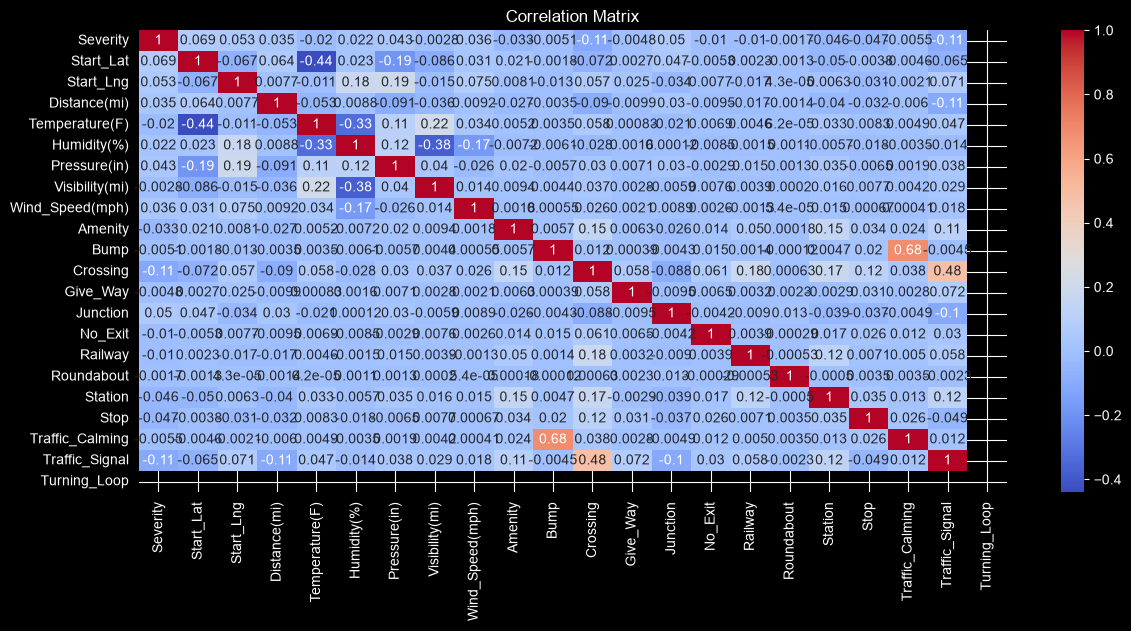

In [18]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(14,6))
sns.heatmap(corr, cmap='coolwarm',annot=True)
plt.title('Correlation Matrix')
plt.show()

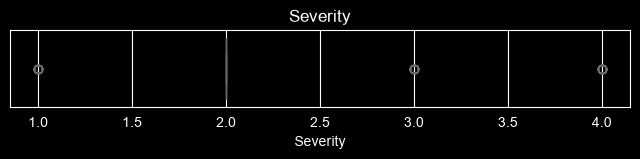

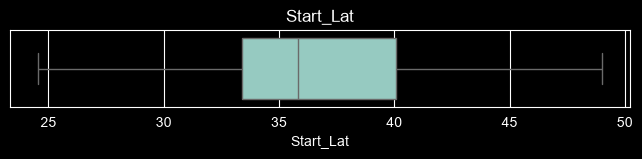

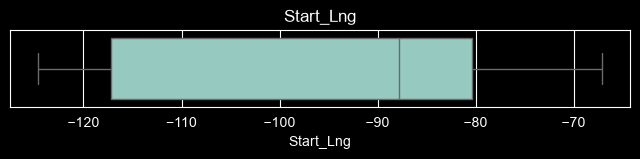

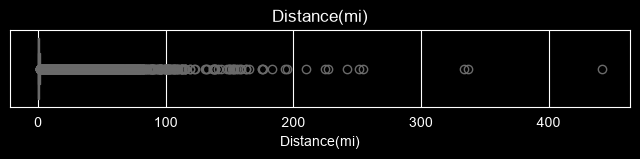

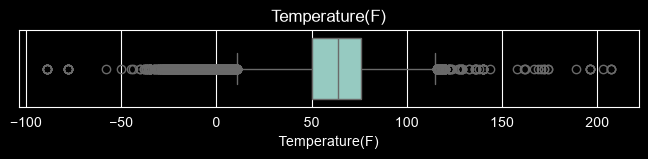

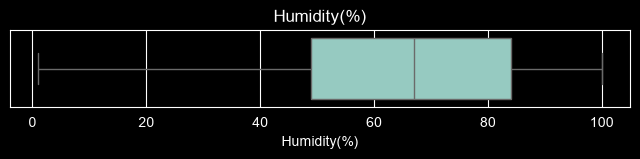

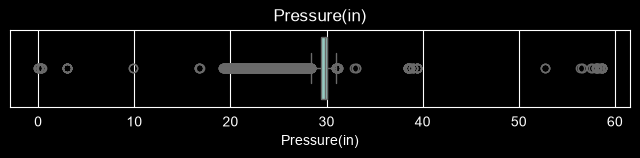

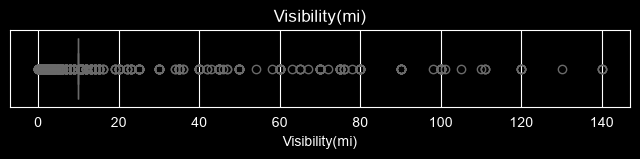

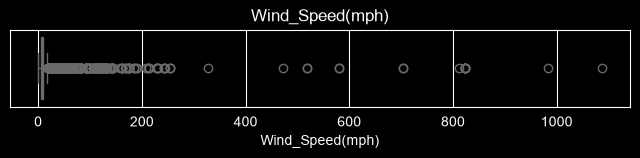

In [19]:
numeric_df = df.select_dtypes(include='number')
for col in numeric_df.columns:
    plt.figure(figsize=(8,1))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [20]:
df['Start_Time'] = pd.to_datetime(df['Start_Time'],errors="coerce")
df['Start_Time']

0         2016-02-08 05:46:00
1         2016-02-08 06:07:59
2         2016-02-08 06:49:27
3         2016-02-08 07:23:34
4         2016-02-08 07:39:07
                  ...        
7728389   2019-08-23 18:03:25
7728390   2019-08-23 19:11:30
7728391   2019-08-23 19:00:21
7728392   2019-08-23 19:00:21
7728393   2019-08-23 18:52:06
Name: Start_Time, Length: 7705148, dtype: datetime64[us]

In [21]:
df['Year'] = df['Start_Time'].dt.year
df['Month'] = df['Start_Time'].dt.month_name()
df['Hour'] = df['Start_Time'].dt.hour
df['Day_Name'] = df['Start_Time'].dt.day_name()

In [22]:
accidents_per_year = df.groupby('Year').size().reset_index(name='Accidents_count')
accidents_per_year

,Year,Accidents_count
0,2016.0,410790
1,2017.0,717254
2,2018.0,893409
3,2019.0,954279
4,2020.0,1161233
5,2021.0,1407108
6,2022.0,1258177
7,2023.0,165418


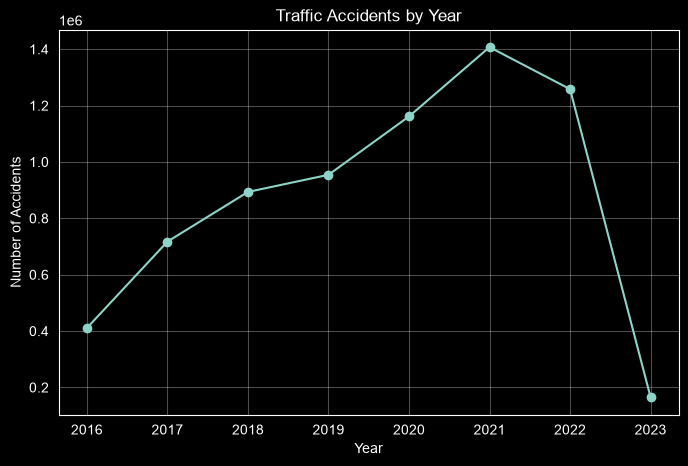

In [23]:
plt.figure(figsize=(8,5))
plt.plot(accidents_per_year['Year'],accidents_per_year['Accidents_count'],marker='o')
plt.title('Traffic Accidents by Year')
plt.xlabel('Year')
plt.ylabel('Number of Accidents')
plt.grid(alpha=0.3)
plt.show()

In [24]:
state_accidents = (
    df.groupby('State')
      .size()
    .head(10)
      .sort_values(ascending=False)
      .reset_index(name='Accidents_Count')
)


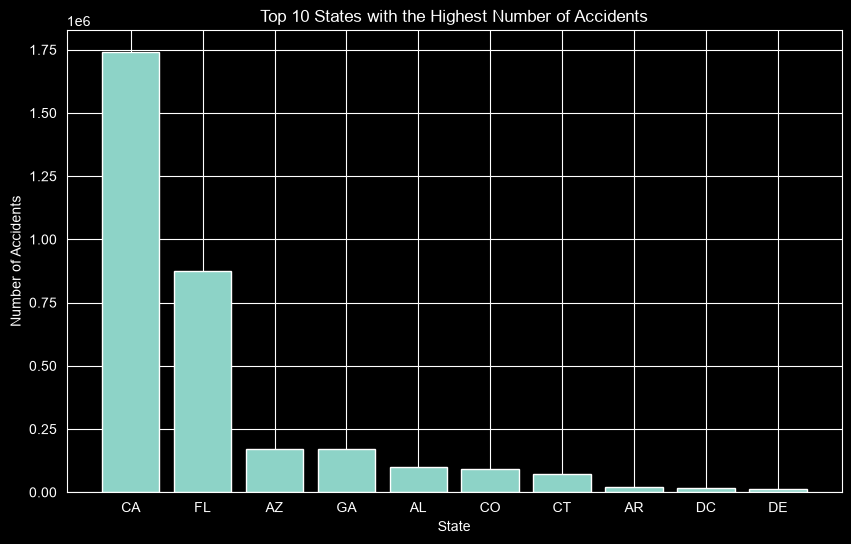

In [25]:
plt.figure(figsize=(10,6))

plt.bar(state_accidents['State'],
        state_accidents['Accidents_Count'])

plt.title('Top 10 States with the Highest Number of Accidents')
plt.xlabel('State')
plt.ylabel('Number of Accidents')

plt.show()

In [26]:
city_accidents = (
    df.groupby('City').size()
    .sort_values(ascending=False)
    .reset_index(name='Accidents_Count')
    .head(10)
)
city_accidents

,City,Accidents_Count
0,Miami,186916
1,Houston,169604
2,Los Angeles,156491
3,Charlotte,138652
4,Dallas,130939
5,Orlando,109733
6,Austin,97359
7,Raleigh,86079
8,Nashville,72930
9,Baton Rouge,71588


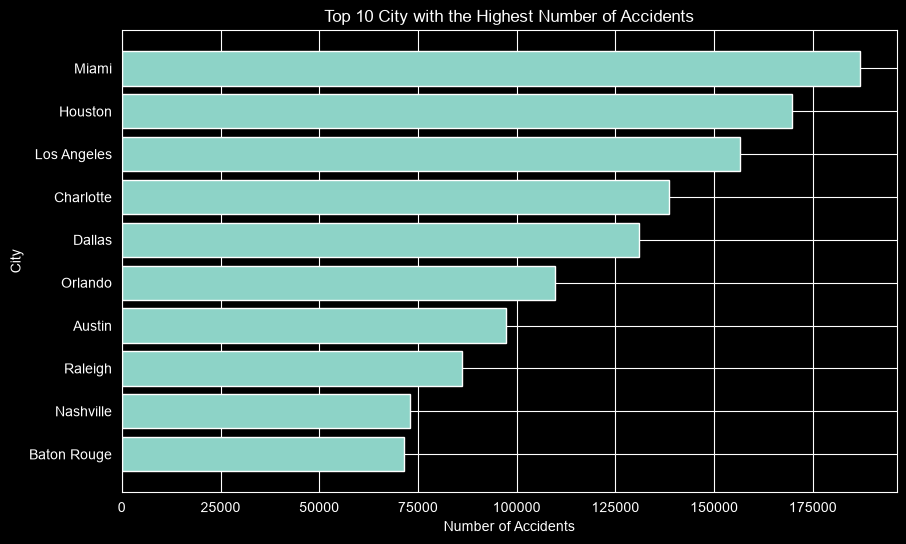

In [27]:
plt.figure(figsize=(10,6))
plt.barh(city_accidents['City'],city_accidents['Accidents_Count'])
plt.title('Top 10 City with the Highest Number of Accidents')
plt.xlabel('Number of Accidents')
plt.ylabel('City')
plt.gca().invert_yaxis()
plt.show()


In [28]:
month_accidents=(
    df.groupby('Month').size()
    .sort_values(ascending=False)
    .reset_index(name='Accidents_Count')
    )
month_accidents

,Month,Accidents_Count
0,December,757154
1,November,694238
2,January,650705
3,October,629196
4,September,592452
5,February,583766
6,August,545772
7,April,524571
8,June,523447
9,May,504311


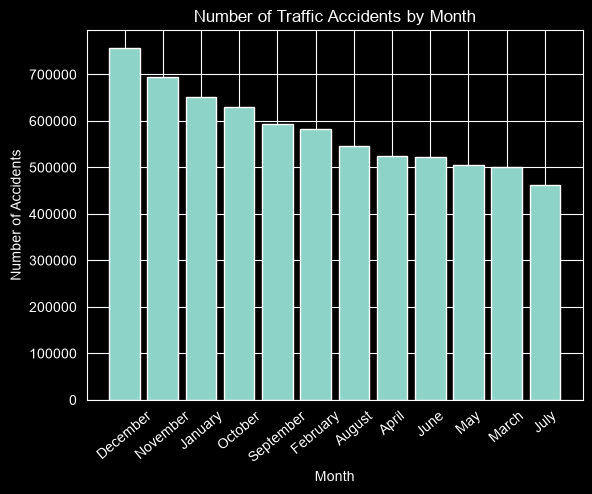

In [29]:
plt.bar(month_accidents['Month'],month_accidents['Accidents_Count'])
plt.title('Number of Traffic Accidents by Month')
plt.xlabel('Month')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=40)
plt.show()

In [31]:
severity_count = (
    df['Severity']
    .value_counts()
    .sort_index()
    .reset_index()
)

severity_count.columns = ['Severity', 'Accidents_Count']

severity_count

,Severity,Accidents_Count
0,1,67162
1,2,6136902
2,3,1298648
3,4,202436


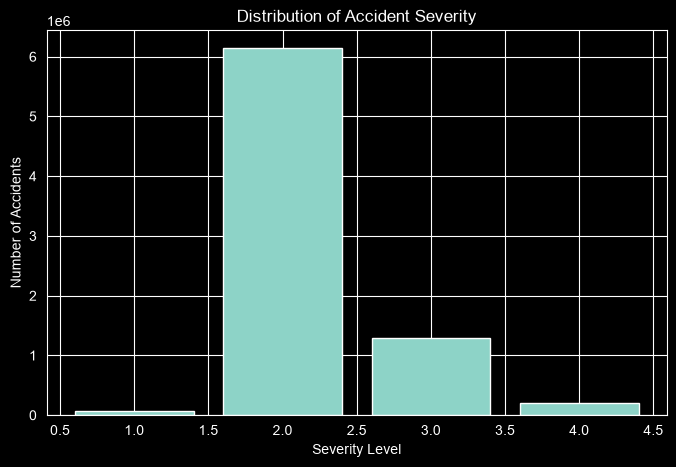

In [32]:
plt.figure(figsize=(8,5))

plt.bar(
    severity_count['Severity'],
    severity_count['Accidents_Count']
)

plt.title('Distribution of Accident Severity')
plt.xlabel('Severity Level')
plt.ylabel('Number of Accidents')

plt.show()

In [33]:
weather_count = (
    df['Weather_Condition']
    .value_counts()
    .head(10)
    .reset_index()
)

weather_count.columns = ['Weather_Condition', 'Accidents_Count']

weather_count

,Weather_Condition,Accidents_Count
0,Fair,2721397
1,Mostly Cloudy,1014209
2,Cloudy,814076
3,Clear,808714
4,Partly Cloudy,697371
5,Overcast,382856
6,Light Rain,351979
7,Scattered Clouds,204820
8,Light Snow,128092
9,Fog,98932


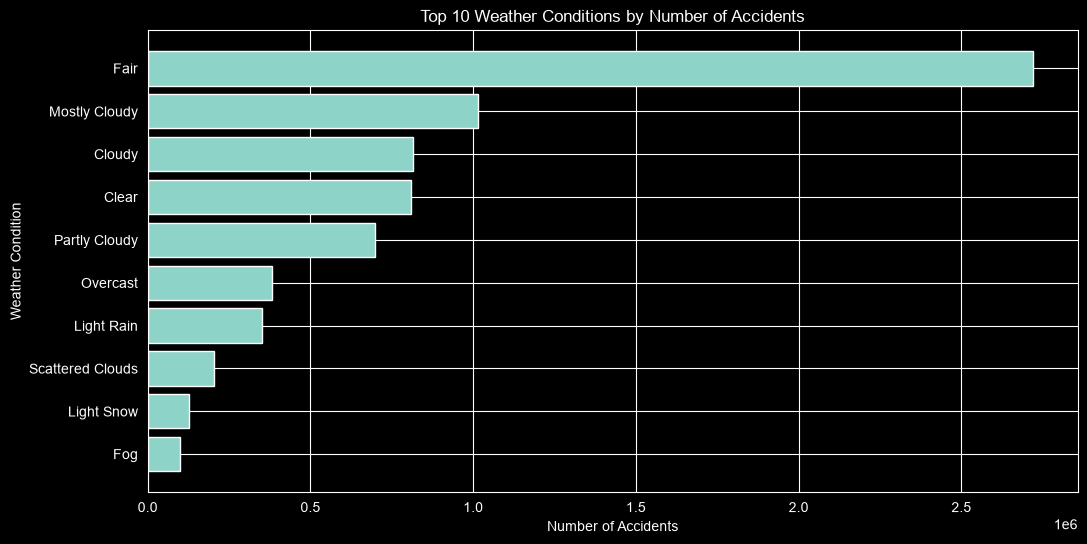

In [36]:
plt.figure(figsize=(12,6))

plt.barh(
    weather_count['Weather_Condition'],
    weather_count['Accidents_Count']
)

plt.title('Top 10 Weather Conditions by Number of Accidents')
plt.xlabel('Number of Accidents')
plt.ylabel('Weather Condition')

plt.gca().invert_yaxis()

plt.show()

In [40]:
visibility = (
    df.groupby('Severity')['Visibility(mi)']
      .mean()
      .reset_index()
)

visibility

,Severity,Visibility(mi)
0,1,9.483166
1,2,9.107144
2,3,9.114163
3,4,9.094166


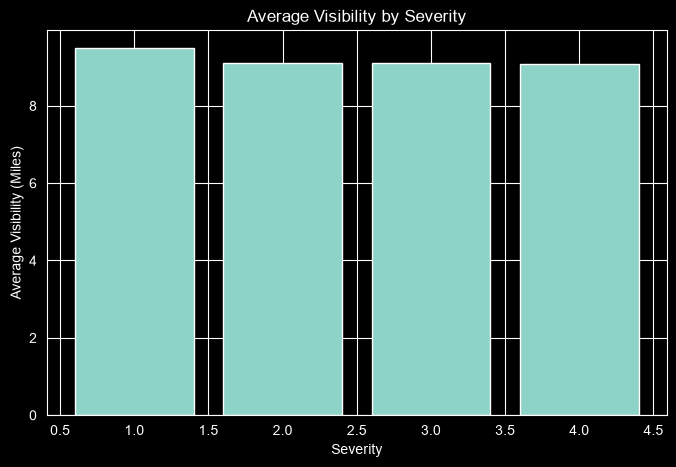

In [41]:
plt.figure(figsize=(8,5))

plt.bar(
    visibility['Severity'],
    visibility['Visibility(mi)']
)

plt.title('Average Visibility by Severity')
plt.xlabel('Severity')
plt.ylabel('Average Visibility (Miles)')

plt.show()

In [42]:
temperature = (
    df.groupby('Severity')['Temperature(F)']
      .mean()
      .reset_index()
)

temperature

,Severity,Temperature(F)
0,1,72.275190
1,2,61.602158
2,3,62.235048
3,4,58.331004


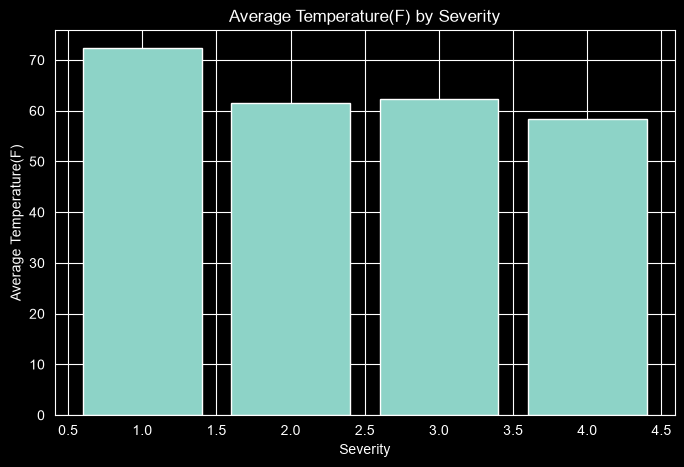

In [44]:
plt.figure(figsize=(8,5))

plt.bar(
    temperature['Severity'],
    temperature['Temperature(F)']
)

plt.title('Average Temperature(F) by Severity')
plt.xlabel('Severity')
plt.ylabel('Average Temperature(F)')

plt.show()

In [45]:
day_night = (
    df['Sunrise_Sunset']
    .value_counts()
    .reset_index()
)

day_night.columns = ['Time_of_Day', 'Accidents_Count']

day_night

,Time_of_Day,Accidents_Count
0,Day,5334553
1,Night,2370595


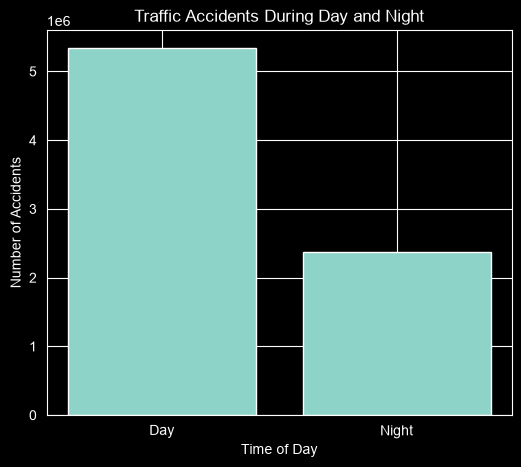

In [46]:
plt.figure(figsize=(6,5))

plt.bar(
    day_night['Time_of_Day'],
    day_night['Accidents_Count']
)

plt.title('Traffic Accidents During Day and Night')
plt.xlabel('Time of Day')
plt.ylabel('Number of Accidents')

plt.show()